In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, f1_score, confusion_matrix
%matplotlib inline

In [17]:
# Load the data
df = pd.read_csv('../data/wheat_prices.csv')

# Convert date column to datetime and sort
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Quick check
print(df.head())
print(df.info())

        date       price
0 2000-01-01  151.082713
1 2000-01-02  151.659654
2 2000-01-03  147.851714
3 2000-01-04  152.937895
4 2000-01-05  152.473119
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    8000 non-null   datetime64[ns]
 1   price   8000 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 125.1 KB
None


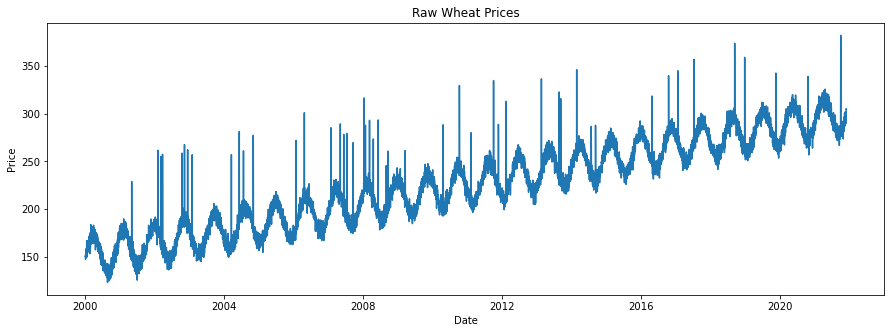

In [18]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['price'])
plt.title('Raw Wheat Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

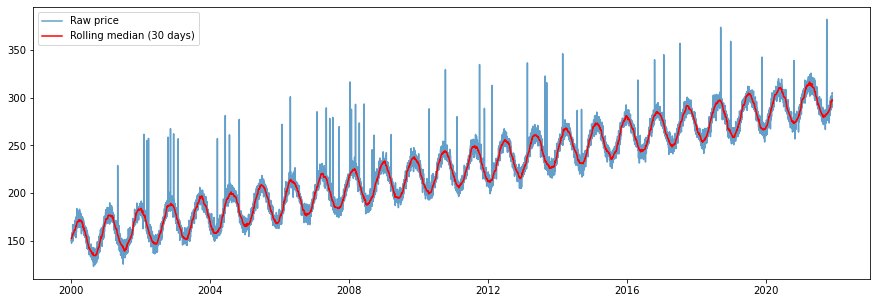

In [19]:
# Choose a window size (e.g., 30 days for monthly seasonality)
window = 30

df['rolling_median'] = df['price'].rolling(window=window, center=True, min_periods=1).median()

# Plot raw price and rolling median
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['price'], label='Raw price', alpha=0.7)
plt.plot(df['date'], df['rolling_median'], label=f'Rolling median ({window} days)', color='red')
plt.legend()
plt.show()

In [20]:
# Residuals
df['residual'] = df['price'] - df['rolling_median']

# (Optional) Normalized residual
df['residual_norm'] = df['residual'] / (df['rolling_median'] + 1e-6)

# Create feature matrix
features = df[['price', 'residual']].copy()

In [21]:
# Example: define anomalies as points where absolute residual > 2 * std(residual)
std_residual = df['residual'].std()
df['true_anomaly'] = (np.abs(df['residual']) > 2 * std_residual).astype(int)

print("Number of true anomalies:", df['true_anomaly'].sum())

Number of true anomalies: 60


In [22]:
# Prepare data for Isolation Forest (without seasonal adjustment)
X_raw = df[['price']].values

# Initialize model (set contamination as estimated proportion of anomalies)
# We'll use the true anomaly proportion as a starting point
contamination = df['true_anomaly'].mean()
iso_raw = IsolationForest(contamination=contamination, random_state=42)
df['anomaly_raw'] = iso_raw.fit_predict(X_raw)

# Convert predictions: 1 for normal, -1 for anomaly -> map to 0/1 for evaluation
df['anomaly_raw'] = df['anomaly_raw'].map({1:0, -1:1})

# Evaluate baseline
print("Baseline (raw prices):")
print(classification_report(df['true_anomaly'], df['anomaly_raw'], target_names=['normal','anomaly']))
print("F1 score:", f1_score(df['true_anomaly'], df['anomaly_raw']))

Baseline (raw prices):
              precision    recall  f1-score   support

      normal       0.99      0.99      0.99      7940
     anomaly       0.25      0.25      0.25        60

    accuracy                           0.99      8000
   macro avg       0.62      0.62      0.62      8000
weighted avg       0.99      0.99      0.99      8000

F1 score: 0.25


In [23]:
X_adj = df[['price', 'residual']].values

iso_adj = IsolationForest(contamination=contamination, random_state=42)
df['anomaly_adj'] = iso_adj.fit_predict(X_adj)
df['anomaly_adj'] = df['anomaly_adj'].map({1:0, -1:1})

print("\nWith seasonal adjustment (rolling median):")
print(classification_report(df['true_anomaly'], df['anomaly_adj'], target_names=['normal','anomaly']))
print("F1 score:", f1_score(df['true_anomaly'], df['anomaly_adj']))


With seasonal adjustment (rolling median):
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00      7940
     anomaly       0.85      0.85      0.85        60

    accuracy                           1.00      8000
   macro avg       0.92      0.92      0.92      8000
weighted avg       1.00      1.00      1.00      8000

F1 score: 0.85


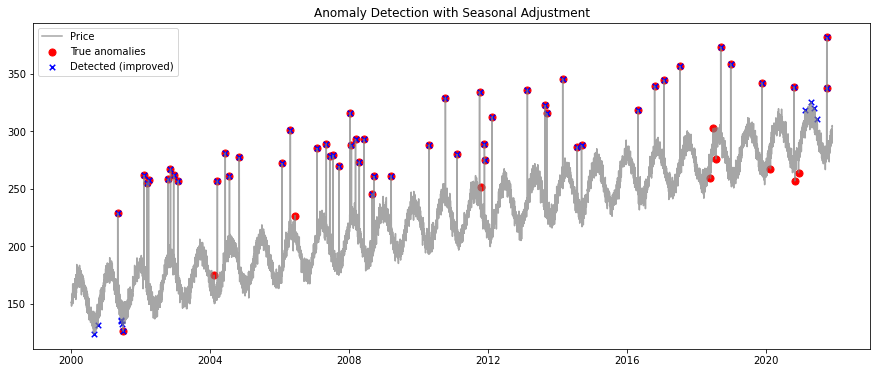

In [24]:
plt.figure(figsize=(15,6))

# Plot price
plt.plot(df['date'], df['price'], label='Price', color='gray', alpha=0.7)

# Mark true anomalies
true_anom = df[df['true_anomaly']==1]
plt.scatter(true_anom['date'], true_anom['price'], color='red', s=50, label='True anomalies', marker='o')

# Mark detected anomalies (improved model)
detected_anom = df[df['anomaly_adj']==1]
plt.scatter(detected_anom['date'], detected_anom['price'], color='blue', s=30, label='Detected (improved)', marker='x')

plt.legend()
plt.title('Anomaly Detection with Seasonal Adjustment')
plt.show()

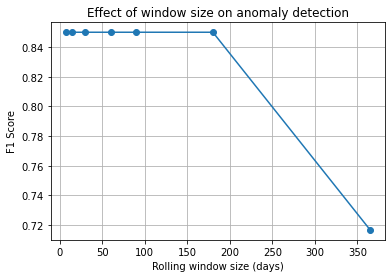

In [25]:
windows = [7, 14, 30, 60, 90, 180, 365]
results = []

for w in windows:
    # Recompute rolling median
    df['rolling_med'] = df['price'].rolling(window=w, center=True, min_periods=1).median()
    df['resid'] = df['price'] - df['rolling_med']
    X = df[['price', 'resid']].values
    
    iso = IsolationForest(contamination=contamination, random_state=42)
    pred = iso.fit_predict(X)
    pred = pd.Series(pred).map({1:0, -1:1})
    
    f1 = f1_score(df['true_anomaly'], pred)
    results.append((w, f1))

# Plot F1 vs window
wins, f1s = zip(*results)
plt.plot(wins, f1s, marker='o')
plt.xlabel('Rolling window size (days)')
plt.ylabel('F1 Score')
plt.title('Effect of window size on anomaly detection')
plt.grid(True)
plt.show()